# 🛒 Rossmann Sales Forecasting & Performance Analytics

## Project Overview
This project combines **Data Analytics** and **Machine Learning** to:
- Analyze sales trends, store performance, and promotion impact
- Build a forecasting model to predict future sales

## Dataset
- **Source:** Rossmann Store Sales (Kaggle)
- **Size:** 1M+ rows across 1,115 stores (2013–2015)

## Notebook Index
1. `01_EDA.ipynb` — Exploratory Data Analysis ← You are here
2. `02_Feature_Engineering.ipynb` — Feature Engineering
3. `03_Model_Training.ipynb` — ML Model (Google Colab)
4. `04_Dashboard.ipynb` — Dashboard Building

## Step 1 — Import Libraries
Loading all required libraries for data analysis and visualization.

In [1]:
# ── Standard libraries ──────────────────────────────────────────
import pandas as pd        # Data manipulation
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Static plots
import seaborn as sns      # Statistical visualizations
import plotly.express as px  # Interactive plots

# ── Display settings ─────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places
sns.set_theme(style="whitegrid")             # Clean plot style
plt.rcParams['figure.figsize'] = (12, 5)    # Default figure size

# ── Version check ────────────────────────────────────────────────
print("✅ pandas     :", pd.__version__)
print("✅ numpy      :", np.__version__)
print("✅ seaborn    :", sns.__version__)
print("✅ All libraries loaded successfully!")

✅ pandas     : 3.0.2
✅ numpy      : 2.4.4
✅ seaborn    : 0.13.2
✅ All libraries loaded successfully!


## Step 2 — Load Dataset
Loading all 3 files and doing a first look at the data.

In [2]:
# ── Define file paths ────────────────────────────────────────────
TRAIN_PATH = '../data/raw/train.csv'
TEST_PATH  = '../data/raw/test.csv'
STORE_PATH = '../data/raw/store.csv'

# ── Load data ────────────────────────────────────────────────────
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test  = pd.read_csv(TEST_PATH,  low_memory=False)
store = pd.read_csv(STORE_PATH)

# ── Basic shape check ────────────────────────────────────────────
print("📦 train shape :", train.shape)
print("📦 test shape  :", test.shape)
print("📦 store shape :", store.shape)
print()
print("✅ All files loaded successfully!")

📦 train shape : (1017209, 9)
📦 test shape  : (41088, 8)
📦 store shape : (1115, 10)

✅ All files loaded successfully!


## Step 3 — First Look at Data
Previewing first few rows of each file to understand the structure.

In [3]:
# ── Preview train data ───────────────────────────────────────────
print("═" * 60)
print("📋 TRAIN DATA — First 5 rows")
print("═" * 60)
display(train.head())

# ── Preview store data ───────────────────────────────────────────
print("═" * 60)
print("📋 STORE DATA — First 5 rows")
print("═" * 60)
display(store.head())

# ── Preview test data ────────────────────────────────────────────
print("═" * 60)
print("📋 TEST DATA — First 5 rows")
print("═" * 60)
display(test.head())

════════════════════════════════════════════════════════════
📋 TRAIN DATA — First 5 rows
════════════════════════════════════════════════════════════


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


════════════════════════════════════════════════════════════
📋 STORE DATA — First 5 rows
════════════════════════════════════════════════════════════


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.00,9.00,2008.00,0,NaN,NaN,NaN
1,2,a,a,570.00,11.00,2007.00,1,13.00,2010.00,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.00,12.00,2006.00,1,14.00,2011.00,"Jan,Apr,Jul,Oct"
3,4,c,c,620.00,9.00,2009.00,0,NaN,NaN,NaN
4,5,a,a,29910.00,4.00,2015.00,0,NaN,NaN,NaN


════════════════════════════════════════════════════════════
📋 TEST DATA — First 5 rows
════════════════════════════════════════════════════════════


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.00,1,0,0
1,2,3,4,2015-09-17,1.00,1,0,0
2,3,7,4,2015-09-17,1.00,1,0,0
3,4,8,4,2015-09-17,1.00,1,0,0
4,5,9,4,2015-09-17,1.00,1,0,0


## Step 4 — Missing Value Analysis
Checking null values across all 3 files to understand data quality.

In [4]:
# ── Null check for train ─────────────────────────────────────────
print("═" * 50)
print("🔍 TRAIN — Missing Values")
print("═" * 50)
null_train = pd.DataFrame({
    'Missing Count' : train.isnull().sum(),
    'Missing %'     : (train.isnull().sum() / len(train) * 100).round(2)
})
display(null_train[null_train['Missing Count'] > 0] if null_train['Missing Count'].sum() > 0 else print("✅ No missing values!"))

# ── Null check for store ─────────────────────────────────────────
print("═" * 50)
print("🔍 STORE — Missing Values")
print("═" * 50)
null_store = pd.DataFrame({
    'Missing Count' : store.isnull().sum(),
    'Missing %'     : (store.isnull().sum() / len(store) * 100).round(2)
})
display(null_store[null_store['Missing Count'] > 0])

# ── Null check for test ──────────────────────────────────────────
print("═" * 50)
print("🔍 TEST — Missing Values")
print("═" * 50)
null_test = pd.DataFrame({
    'Missing Count' : test.isnull().sum(),
    'Missing %'     : (test.isnull().sum() / len(test) * 100).round(2)
})
display(null_test[null_test['Missing Count'] > 0] if null_test['Missing Count'].sum() > 0 else print("✅ No missing values!"))

══════════════════════════════════════════════════
🔍 TRAIN — Missing Values
══════════════════════════════════════════════════
✅ No missing values!


None

══════════════════════════════════════════════════
🔍 STORE — Missing Values
══════════════════════════════════════════════════


,Missing Count,Missing %
CompetitionDistance,3,0.27
CompetitionOpenSinceMonth,354,31.75
CompetitionOpenSinceYear,354,31.75
Promo2SinceWeek,544,48.79
Promo2SinceYear,544,48.79
PromoInterval,544,48.79


══════════════════════════════════════════════════
🔍 TEST — Missing Values
══════════════════════════════════════════════════


,Missing Count,Missing %
Open,11,0.03


## Step 5 — Handle Missing Values
Filling null values with appropriate logic for each column.

In [5]:
# ── Fix store.csv nulls ──────────────────────────────────────────

# CompetitionDistance — fill with median
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

# Competition open since — fill with 0
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0)
store['CompetitionOpenSinceYear']  = store['CompetitionOpenSinceYear'].fillna(0)

# Promo2 fields — fill with 0
store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(0)
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(0)

# PromoInterval — fill with 'None'
store['PromoInterval'] = store['PromoInterval'].fillna('None')

# ── Fix test.csv nulls ───────────────────────────────────────────
test['Open'] = test['Open'].fillna(1)

# ── Verify ───────────────────────────────────────────────────────
print("✅ store.csv remaining nulls:", store.isnull().sum().sum())
print("✅ test.csv remaining nulls :", test.isnull().sum().sum())
print()
print("🎉 All missing values handled!")

✅ store.csv remaining nulls: 0
✅ test.csv remaining nulls : 0

🎉 All missing values handled!


## Step 6 — Merge Train & Store Data
Combining train.csv with store.csv on Store ID to get 
store metadata (type, assortment, competition, promo) 
alongside sales data.

In [6]:
# ── Merge train with store on 'Store' column ─────────────────────
df = pd.merge(train, store, on='Store', how='left')

# ── Convert Date column to datetime format ────────────────────────
df['Date'] = pd.to_datetime(df['Date'])

# ── Verify merge ─────────────────────────────────────────────────
print("📦 train shape        :", train.shape)
print("📦 store shape        :", store.shape)
print("📦 merged shape       :", df.shape)
print()
print("📅 Date range         :", df['Date'].min(), "→", df['Date'].max())
print("🏪 Total stores       :", df['Store'].nunique())
print("📋 Total columns      :", df.columns.tolist())
print()
print("✅ Merge successful!")

📦 train shape        : (1017209, 9)
📦 store shape        : (1115, 10)
📦 merged shape       : (1017209, 18)

📅 Date range         : 2013-01-01 00:00:00 → 2015-07-31 00:00:00
🏪 Total stores       : 1115
📋 Total columns      : ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

✅ Merge successful!


## Step 7 — Save Cleaned Data
Saving the merged and cleaned dataframe to data/processed/ 
so we can directly load it in future notebooks.

In [7]:
# ── Save merged dataframe to processed folder ─────────────────────
df.to_csv('../data/processed/train_cleaned.csv', index=False)

# ── Verify file saved ─────────────────────────────────────────────
import os
file_path = '../data/processed/train_cleaned.csv'
file_size = os.path.getsize(file_path) / (1024 * 1024)  # Convert to MB

print(f"✅ File saved successfully!")
print(f"📁 Location : data/processed/train_cleaned.csv")
print(f"📦 File size: {file_size:.2f} MB")
print(f"📋 Shape    : {df.shape}")
print()
print("🎉 Phase 1 — Data Loading & Cleaning COMPLETE!")

✅ File saved successfully!
📁 Location : data/processed/train_cleaned.csv
📦 File size: 76.66 MB
📋 Shape    : (1017209, 18)

🎉 Phase 1 — Data Loading & Cleaning COMPLETE!


## Step 8 — Sales Trend Analysis
Analyzing how total sales behave over time — monthly, weekly patterns.
### 8.1 — Monthly Sales Trend

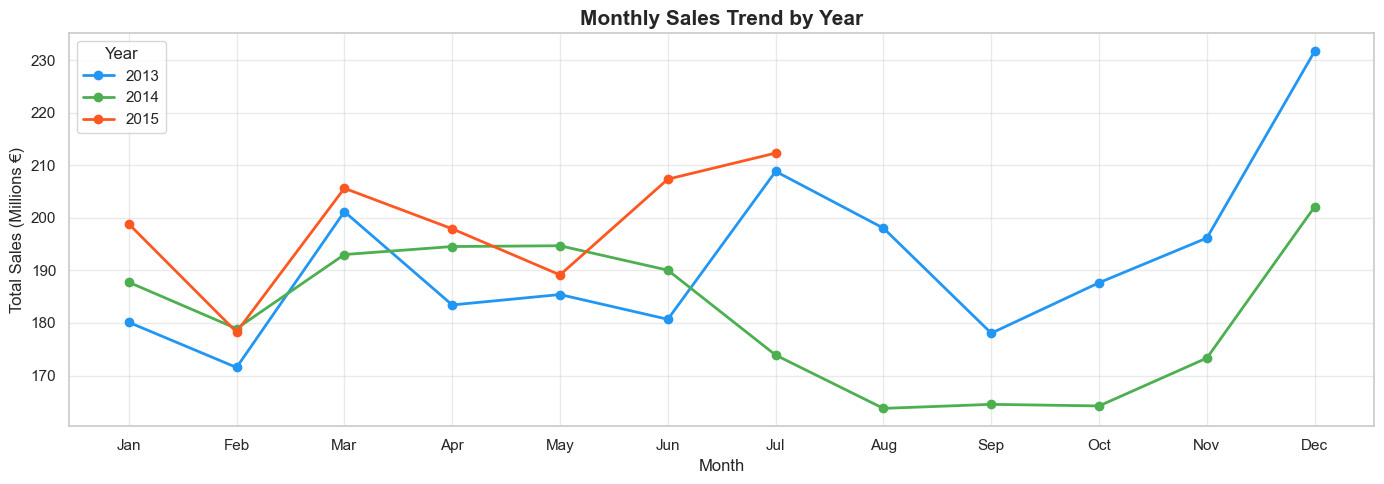

📊 Total Sales by Year:
Year
2013    €2302.9M
2014    €2180.8M
2015    €1389.5M
Name: Sales, dtype: str


In [8]:
# ── Aggregate sales by month ──────────────────────────────────────
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week']  = df['Date'].dt.isocalendar().week.astype(int)

monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = pd.to_datetime(
    monthly_sales['Year'].astype(str) + '-' + 
    monthly_sales['Month'].astype(str)
)
monthly_sales = monthly_sales.sort_values('YearMonth')

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

for year, color in zip([2013, 2014, 2015], ['#2196F3', '#4CAF50', '#FF5722']):
    data = monthly_sales[monthly_sales['Year'] == year]
    ax.plot(data['Month'], data['Sales'] / 1e6, 
            marker='o', label=str(year), color=color, linewidth=2)

# ── Formatting ────────────────────────────────────────────────────
ax.set_title('Monthly Sales Trend by Year', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (Millions €)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Year')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ── Key numbers ───────────────────────────────────────────────────
print("📊 Total Sales by Year:")
print(df.groupby('Year')['Sales'].sum().apply(lambda x: f"€{x/1e6:.1f}M"))

### 8.2 — Day of Week Sales Pattern
Analyzing which days of the week generate the most sales.

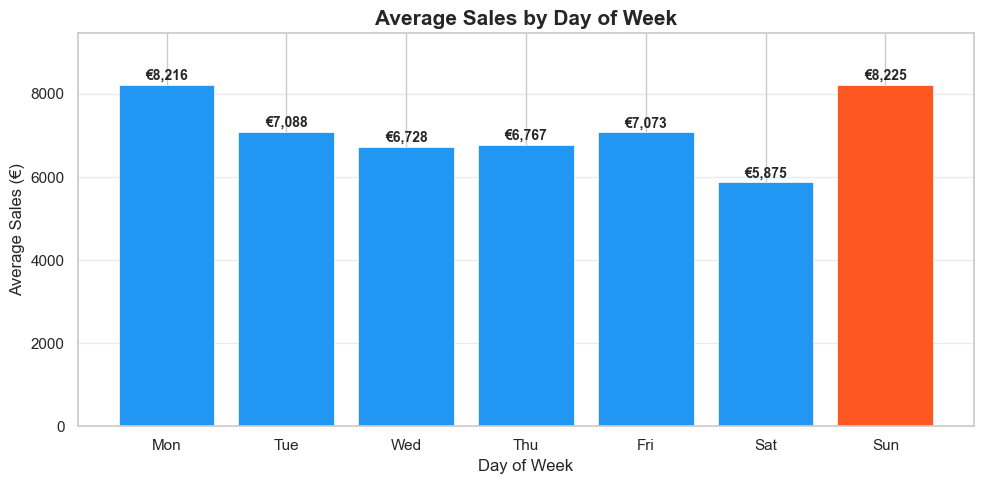

📊 Average Sales by Day:
  Mon : €8,216  ████████████████
  Tue : €7,088  ██████████████
  Wed : €6,728  █████████████
  Thu : €6,767  █████████████
  Fri : €7,073  ██████████████
  Sat : €5,875  ███████████
  Sun : €8,225  ████████████████


In [9]:
# ── Filter only open stores ───────────────────────────────────────
df_open = df[df['Open'] == 1]

# ── Average sales by day of week ─────────────────────────────────
day_sales = df_open.groupby('DayOfWeek')['Sales'].mean().reset_index()
day_sales['DayName'] = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2196F3' if s < day_sales['Sales'].max() 
          else '#FF5722' for s in day_sales['Sales']]

bars = ax.bar(day_sales['DayName'], day_sales['Sales'], 
              color=colors, edgecolor='white', linewidth=0.5)

# ── Add value labels on bars ──────────────────────────────────────
for bar, val in zip(bars, day_sales['Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 50,
            f'€{val:,.0f}', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

# ── Formatting ────────────────────────────────────────────────────
ax.set_title('Average Sales by Day of Week', fontsize=15, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Sales (€)')
ax.set_ylim(0, day_sales['Sales'].max() * 1.15)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Key numbers ───────────────────────────────────────────────────
print("📊 Average Sales by Day:")
for _, row in day_sales.iterrows():
    bar = "█" * int(row['Sales'] / 500)
    print(f"  {row['DayName']} : €{row['Sales']:,.0f}  {bar}")

### 8.3 — Sales Heatmap (Month vs Day of Week)
Visualizing sales intensity across months and days — 
helps identify best and worst performing time combinations.

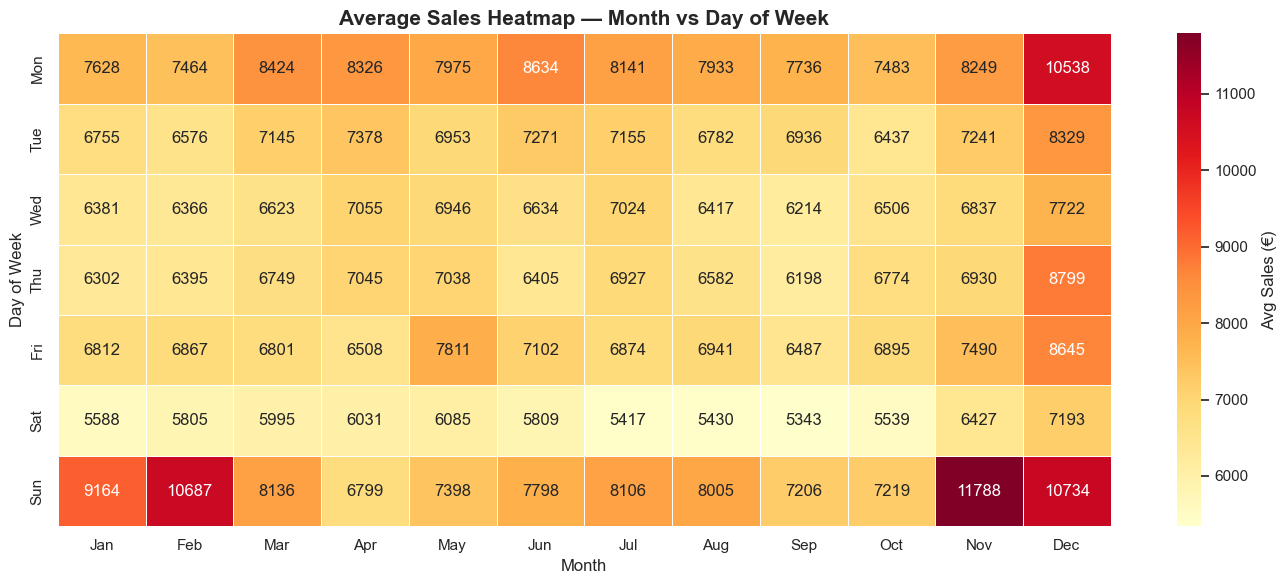

🔴 Darker red = Higher sales
🟡 Lighter yellow = Lower sales

📊 Highest avg sales cell: €11,788 — ('Sun', 'Nov')
📊 Lowest avg sales cell : €5,343 — ('Sat', 'Sep')


In [10]:
# ── Aggregate average sales by Month and DayOfWeek ───────────────
heatmap_data = df_open.groupby(['Month', 'DayOfWeek'])['Sales'].mean().reset_index()

# ── Pivot for heatmap format ──────────────────────────────────────
heatmap_pivot = heatmap_data.pivot(index='DayOfWeek', 
                                    columns='Month', 
                                    values='Sales')

# ── Rename axes ───────────────────────────────────────────────────
heatmap_pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heatmap_pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(heatmap_pivot, 
            annot=True,           # Show values in cells
            fmt='.0f',            # No decimal places
            cmap='YlOrRd',        # Yellow to Red color scale
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Avg Sales (€)'})

# ── Formatting ────────────────────────────────────────────────────
ax.set_title('Average Sales Heatmap — Month vs Day of Week', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

print("🔴 Darker red = Higher sales")
print("🟡 Lighter yellow = Lower sales")
print()
print("📊 Highest avg sales cell:", 
      f"€{heatmap_pivot.max().max():,.0f}",
      "—", heatmap_pivot.stack().idxmax())
print("📊 Lowest avg sales cell :", 
      f"€{heatmap_pivot.min().min():,.0f}",
      "—", heatmap_pivot.stack().idxmin())

## Step 9 — Store Performance Analysis
Identifying top and bottom performing stores by total sales.
Helps understand what makes a store successful.
### 9.1 — Top 10 vs Bottom 10 Stores

C:\Users\AKASH KUMAR\AppData\Local\Temp\ipykernel_19644\238319467.py:41: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\AKASH KUMAR\AppData\Local\Temp\ipykernel_19644\238319467.py:41: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
e:\Sales Forecasting\sales\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Sales Forecasting\sales\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


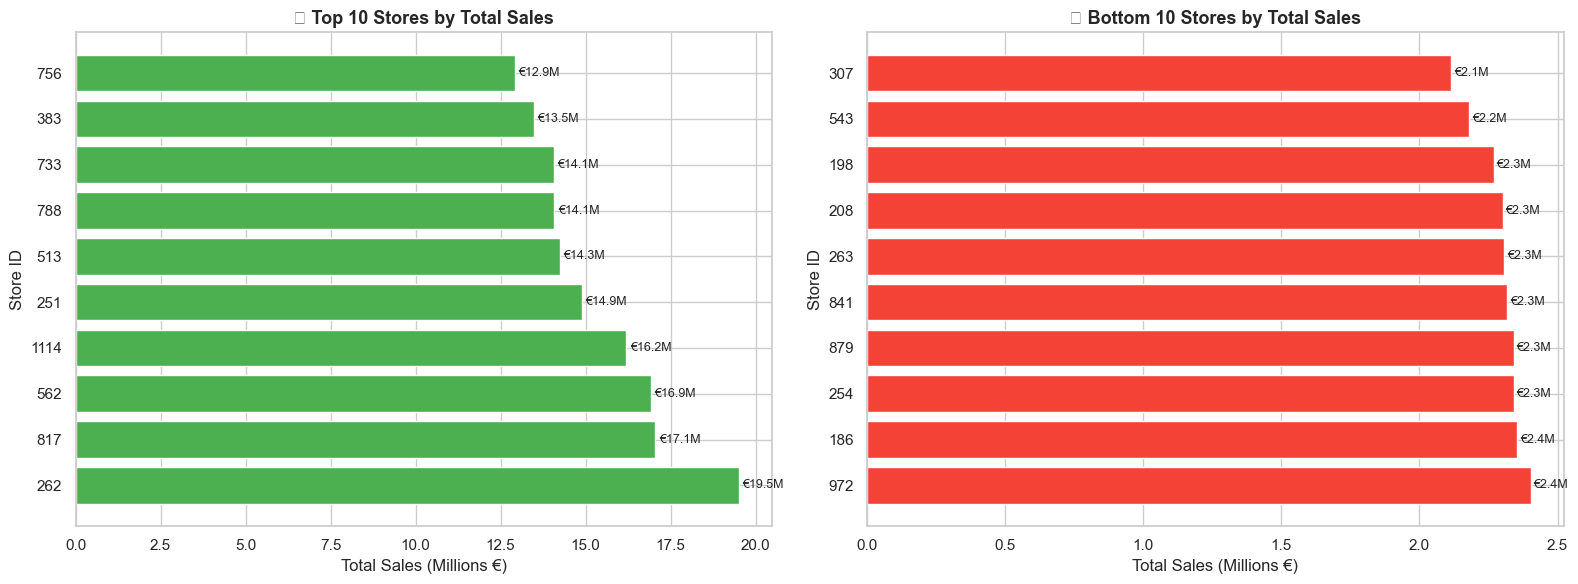

🏆 Best store  : Store 262 — €19.5M total sales
📉 Worst store : Store 972 — €2.4M total sales
📊 Gap between best & worst: €17.1M


In [11]:
# ── Total sales per store ─────────────────────────────────────────
store_sales = df_open.groupby('Store').agg(
    Total_Sales    = ('Sales', 'sum'),
    Avg_Sales      = ('Sales', 'mean'),
    Total_Customers= ('Customers', 'sum'),
    Avg_Customers  = ('Customers', 'mean'),
    Total_Days     = ('Sales', 'count')
).reset_index().sort_values('Total_Sales', ascending=False)

# ── Top 10 and Bottom 10 ──────────────────────────────────────────
top10    = store_sales.head(10)
bottom10 = store_sales.tail(10)

# ── Plot side by side ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
axes[0].barh(top10['Store'].astype(str), 
             top10['Total_Sales'] / 1e6,
             color='#4CAF50', edgecolor='white')
axes[0].set_title('🏆 Top 10 Stores by Total Sales', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Sales (Millions €)')
axes[0].set_ylabel('Store ID')
for i, (val, store) in enumerate(zip(top10['Total_Sales'], top10['Store'])):
    axes[0].text(val/1e6 + 0.1, i, f'€{val/1e6:.1f}M', 
                va='center', fontsize=9)

# Bottom 10
axes[1].barh(bottom10['Store'].astype(str), 
             bottom10['Total_Sales'] / 1e6,
             color='#F44336', edgecolor='white')
axes[1].set_title('📉 Bottom 10 Stores by Total Sales', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Sales (Millions €)')
axes[1].set_ylabel('Store ID')
for i, (val, store) in enumerate(zip(bottom10['Total_Sales'], bottom10['Store'])):
    axes[1].text(val/1e6 + 0.01, i, f'€{val/1e6:.1f}M', 
                va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Key stats ─────────────────────────────────────────────────────
print(f"🏆 Best store  : Store {top10.iloc[0]['Store']:,.0f} — €{top10.iloc[0]['Total_Sales']/1e6:.1f}M total sales")
print(f"📉 Worst store : Store {bottom10.iloc[0]['Store']:,.0f} — €{bottom10.iloc[0]['Total_Sales']/1e6:.1f}M total sales")
print(f"📊 Gap between best & worst: €{(top10.iloc[0]['Total_Sales'] - bottom10.iloc[0]['Total_Sales'])/1e6:.1f}M")

### 9.2 — Sales by Store Type & Assortment
Understanding which store format and product range drives more sales.

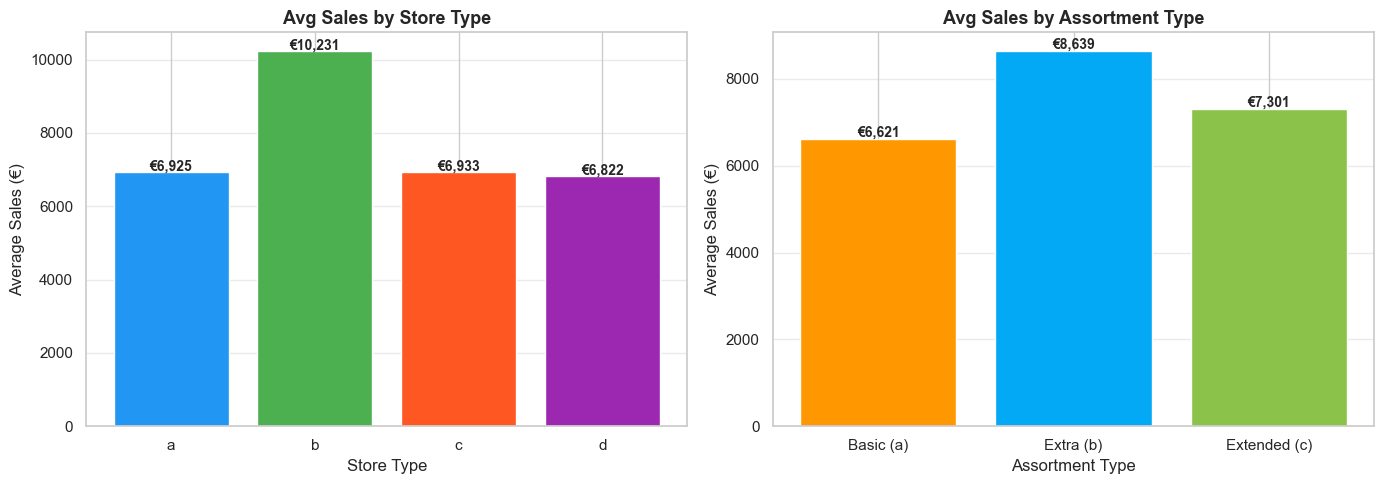

📊 Average Sales by Store Type:
   Type a : €6,925
   Type b : €10,231
   Type c : €6,933
   Type d : €6,822

📊 Average Sales by Assortment:
   Basic (a) : €6,621
   Extra (b) : €8,639
   Extended (c) : €7,301


In [12]:
# ── Average sales by Store Type ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Store Type
storetype_sales = df_open.groupby('StoreType')['Sales'].mean().reset_index()
axes[0].bar(storetype_sales['StoreType'], 
            storetype_sales['Sales'],
            color=['#2196F3','#4CAF50','#FF5722','#9C27B0'],
            edgecolor='white')
axes[0].set_title('Avg Sales by Store Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Average Sales (€)')
axes[0].grid(axis='y', alpha=0.4)
for i, val in enumerate(storetype_sales['Sales']):
    axes[0].text(i, val + 50, f'€{val:,.0f}', 
                ha='center', fontsize=10, fontweight='bold')

# Assortment
assortment_sales = df_open.groupby('Assortment')['Sales'].mean().reset_index()
assortment_sales['Assortment'] = assortment_sales['Assortment'].map(
    {'a': 'Basic (a)', 'b': 'Extra (b)', 'c': 'Extended (c)'})
axes[1].bar(assortment_sales['Assortment'], 
            assortment_sales['Sales'],
            color=['#FF9800','#03A9F4','#8BC34A'],
            edgecolor='white')
axes[1].set_title('Avg Sales by Assortment Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Assortment Type')
axes[1].set_ylabel('Average Sales (€)')
axes[1].grid(axis='y', alpha=0.4)
for i, val in enumerate(assortment_sales['Sales']):
    axes[1].text(i, val + 50, f'€{val:,.0f}', 
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Print summary ─────────────────────────────────────────────────
print("📊 Average Sales by Store Type:")
for _, row in storetype_sales.iterrows():
    print(f"   Type {row['StoreType']} : €{row['Sales']:,.0f}")

print()
print("📊 Average Sales by Assortment:")
for _, row in assortment_sales.iterrows():
    print(f"   {row['Assortment']} : €{row['Sales']:,.0f}")

## Step 10 — Promotion Impact Analysis
Analyzing how promotions affect sales and customer footfall.
Do promotions actually drive more revenue?
### 10.1 — Promo vs Non-Promo Sales

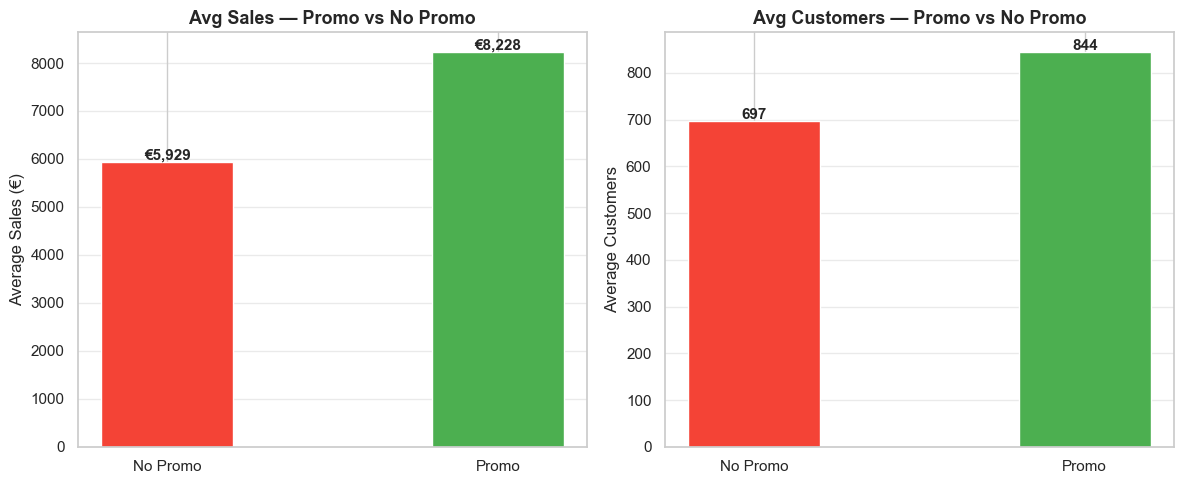

📊 Promo Sales Uplift    : +38.8%
📊 Promo Customer Uplift : +21.2%

💡 Promotions drive 38.8% more sales
💡 Promotions attract 21.2% more customers


In [13]:
# ── Promo vs Non-Promo average sales ─────────────────────────────
promo_sales = df_open.groupby('Promo').agg(
    Avg_Sales     = ('Sales', 'mean'),
    Avg_Customers = ('Customers', 'mean'),
    Total_Days    = ('Sales', 'count')
).reset_index()
promo_sales['Promo'] = promo_sales['Promo'].map({0: 'No Promo', 1: 'Promo'})

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Avg Sales
colors = ['#F44336', '#4CAF50']
bars1 = axes[0].bar(promo_sales['Promo'], promo_sales['Avg_Sales'],
                    color=colors, edgecolor='white', width=0.4)
axes[0].set_title('Avg Sales — Promo vs No Promo', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Sales (€)')
axes[0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars1, promo_sales['Avg_Sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                val + 50, f'€{val:,.0f}',
                ha='center', fontweight='bold', fontsize=11)

# Avg Customers
bars2 = axes[1].bar(promo_sales['Promo'], promo_sales['Avg_Customers'],
                    color=colors, edgecolor='white', width=0.4)
axes[1].set_title('Avg Customers — Promo vs No Promo', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Customers')
axes[1].grid(axis='y', alpha=0.4)
for bar, val in zip(bars2, promo_sales['Avg_Customers']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                val + 5, f'{val:,.0f}',
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ── Uplift calculation ────────────────────────────────────────────
sales_uplift    = ((promo_sales.iloc[1]['Avg_Sales'] - 
                    promo_sales.iloc[0]['Avg_Sales']) / 
                    promo_sales.iloc[0]['Avg_Sales'] * 100)
customer_uplift = ((promo_sales.iloc[1]['Avg_Customers'] - 
                    promo_sales.iloc[0]['Avg_Customers']) / 
                    promo_sales.iloc[0]['Avg_Customers'] * 100)

print(f"📊 Promo Sales Uplift    : +{sales_uplift:.1f}%")
print(f"📊 Promo Customer Uplift : +{customer_uplift:.1f}%")
print()
print(f"💡 Promotions drive {sales_uplift:.1f}% more sales")
print(f"💡 Promotions attract {customer_uplift:.1f}% more customers")

### 10.2 — Promotion Impact by Store Type
Checking if promotions work equally across all store types
or if some store types benefit more from promotions.

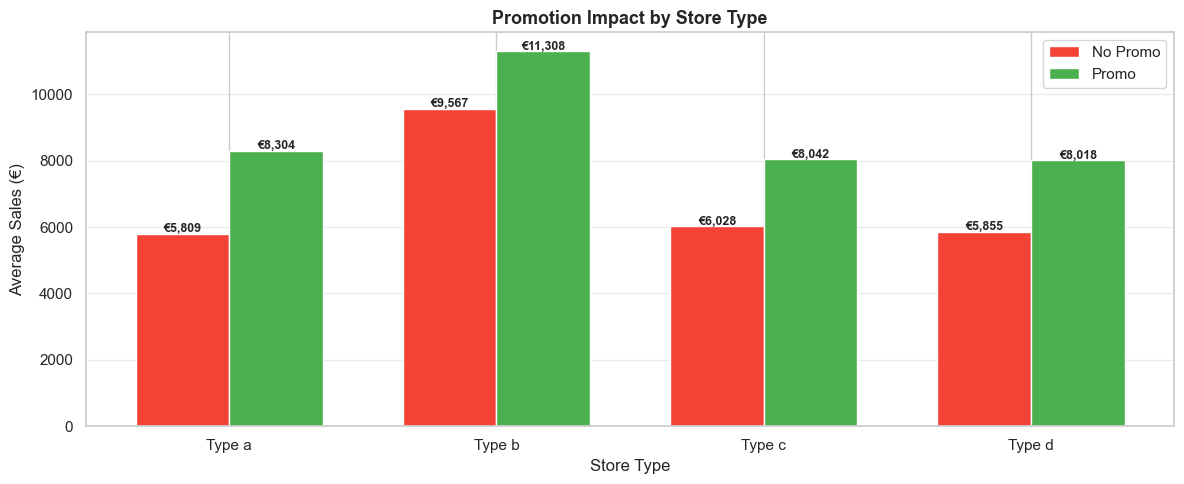

📊 Promo Uplift by Store Type:
----------------------------------------
   Type a : No Promo €5,809 → Promo €8,304 | Uplift: +43.0%
   Type b : No Promo €9,567 → Promo €11,308 | Uplift: +18.2%
   Type c : No Promo €6,028 → Promo €8,042 | Uplift: +33.4%
   Type d : No Promo €5,855 → Promo €8,018 | Uplift: +36.9%


In [14]:
# ── Avg sales by Store Type and Promo ────────────────────────────
promo_storetype = df_open.groupby(['StoreType', 'Promo'])['Sales'].mean().reset_index()
promo_storetype['Promo'] = promo_storetype['Promo'].map({0: 'No Promo', 1: 'Promo'})

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x      = ['Type a', 'Type b', 'Type c', 'Type d']
x_pos  = range(len(x))
width  = 0.35

no_promo = promo_storetype[promo_storetype['Promo'] == 'No Promo']['Sales'].values
promo    = promo_storetype[promo_storetype['Promo'] == 'Promo']['Sales'].values

bars1 = ax.bar([p - width/2 for p in x_pos], no_promo, 
               width, label='No Promo', color='#F44336', edgecolor='white')
bars2 = ax.bar([p + width/2 for p in x_pos], promo,    
               width, label='Promo',    color='#4CAF50', edgecolor='white')

# ── Value labels ──────────────────────────────────────────────────
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'€{bar.get_height():,.0f}',
            ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'€{bar.get_height():,.0f}',
            ha='center', fontsize=9, fontweight='bold')

# ── Formatting ────────────────────────────────────────────────────
ax.set_title('Promotion Impact by Store Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Store Type')
ax.set_ylabel('Average Sales (€)')
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Uplift per store type ─────────────────────────────────────────
print("📊 Promo Uplift by Store Type:")
print("-" * 40)
store_types = ['a', 'b', 'c', 'd']
for st, np_val, p_val in zip(store_types, no_promo, promo):
    uplift = (p_val - np_val) / np_val * 100
    print(f"   Type {st} : No Promo €{np_val:,.0f} → Promo €{p_val:,.0f} | Uplift: +{uplift:.1f}%")

## Step 11 — Holiday Effects on Sales
Analyzing how state holidays and school holidays 
impact sales performance across Rossmann stores.
### 11.1 — State Holiday Impact

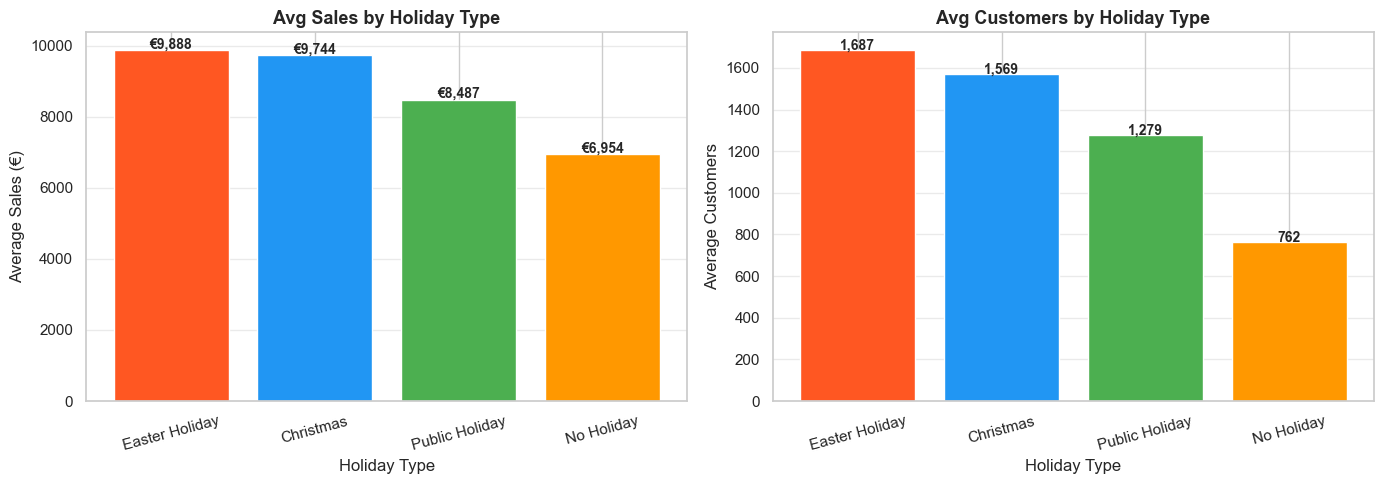

📊 Holiday Impact Summary:
-------------------------------------------------------
   Easter Holiday       | Avg Sales: €9,888 | Days: 145
   Christmas            | Avg Sales: €9,744 | Days: 71
   Public Holiday       | Avg Sales: €8,487 | Days: 694
   No Holiday           | Avg Sales: €6,954 | Days: 843,482


In [15]:
# ── Map StateHoliday codes to meaningful names ────────────────────
df_open['HolidayType'] = df_open['StateHoliday'].map({
    0:   'No Holiday',
    '0': 'No Holiday',
    'a': 'Public Holiday',
    'b': 'Easter Holiday',
    'c': 'Christmas'
})

# ── Average sales by holiday type ────────────────────────────────
holiday_sales = df_open.groupby('HolidayType').agg(
    Avg_Sales     = ('Sales', 'mean'),
    Avg_Customers = ('Customers', 'mean'),
    Count         = ('Sales', 'count')
).reset_index().sort_values('Avg_Sales', ascending=False)

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#FF5722', '#2196F3', '#4CAF50', '#FF9800']

# Avg Sales by Holiday Type
bars = axes[0].bar(holiday_sales['HolidayType'],
                   holiday_sales['Avg_Sales'],
                   color=colors, edgecolor='white')
axes[0].set_title('Avg Sales by Holiday Type',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Holiday Type')
axes[0].set_ylabel('Average Sales (€)')
axes[0].grid(axis='y', alpha=0.4)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, holiday_sales['Avg_Sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                val + 50, f'€{val:,.0f}',
                ha='center', fontweight='bold', fontsize=10)

# Avg Customers by Holiday Type
bars2 = axes[1].bar(holiday_sales['HolidayType'],
                    holiday_sales['Avg_Customers'],
                    color=colors, edgecolor='white')
axes[1].set_title('Avg Customers by Holiday Type',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Holiday Type')
axes[1].set_ylabel('Average Customers')
axes[1].grid(axis='y', alpha=0.4)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, holiday_sales['Avg_Customers']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                val + 2, f'{val:,.0f}',
                ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ── Print summary ─────────────────────────────────────────────────
print("📊 Holiday Impact Summary:")
print("-" * 55)
for _, row in holiday_sales.iterrows():
    print(f"   {row['HolidayType']:<20} | "
          f"Avg Sales: €{row['Avg_Sales']:,.0f} | "
          f"Days: {row['Count']:,}")

### 11.2 — School Holiday Impact

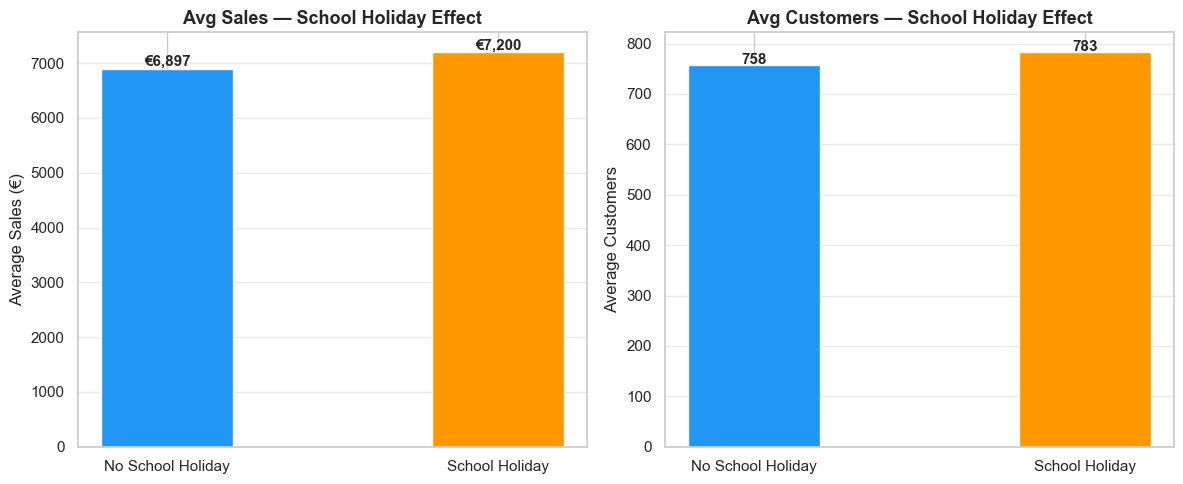

📊 School Holiday Impact:
--------------------------------------------------
   No School Holiday    | Avg Sales: €6,897 | Avg Customers: 758
   School Holiday       | Avg Sales: €7,200 | Avg Customers: 783

💡 School Holiday Sales Uplift: +4.4%


In [16]:
# ── Average sales by school holiday ──────────────────────────────
school_sales = df_open.groupby('SchoolHoliday').agg(
    Avg_Sales     = ('Sales', 'mean'),
    Avg_Customers = ('Customers', 'mean'),
    Count         = ('Sales', 'count')
).reset_index()
school_sales['SchoolHoliday'] = school_sales['SchoolHoliday'].map(
    {0: 'No School Holiday', 1: 'School Holiday'})

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2196F3', '#FF9800']

# Avg Sales
bars1 = axes[0].bar(school_sales['SchoolHoliday'],
                    school_sales['Avg_Sales'],
                    color=colors, edgecolor='white', width=0.4)
axes[0].set_title('Avg Sales — School Holiday Effect',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Sales (€)')
axes[0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars1, school_sales['Avg_Sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                val + 50, f'€{val:,.0f}',
                ha='center', fontweight='bold', fontsize=11)

# Avg Customers
bars2 = axes[1].bar(school_sales['SchoolHoliday'],
                    school_sales['Avg_Customers'],
                    color=colors, edgecolor='white', width=0.4)
axes[1].set_title('Avg Customers — School Holiday Effect',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Customers')
axes[1].grid(axis='y', alpha=0.4)
for bar, val in zip(bars2, school_sales['Avg_Customers']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                val + 2, f'{val:,.0f}',
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ── Uplift ────────────────────────────────────────────────────────
sales_uplift = ((school_sales.iloc[1]['Avg_Sales'] - 
                 school_sales.iloc[0]['Avg_Sales']) / 
                 school_sales.iloc[0]['Avg_Sales'] * 100)

print("📊 School Holiday Impact:")
print("-" * 50)
for _, row in school_sales.iterrows():
    print(f"   {row['SchoolHoliday']:<20} | "
          f"Avg Sales: €{row['Avg_Sales']:,.0f} | "
          f"Avg Customers: {row['Avg_Customers']:,.0f}")
print()
print(f"💡 School Holiday Sales Uplift: {sales_uplift:+.1f}%")

## Step 12 — Correlation Analysis
Identifying which features have strongest relationship with Sales.
This directly guides our feature selection for the ML model.
### 12.1 — Correlation Heatmap

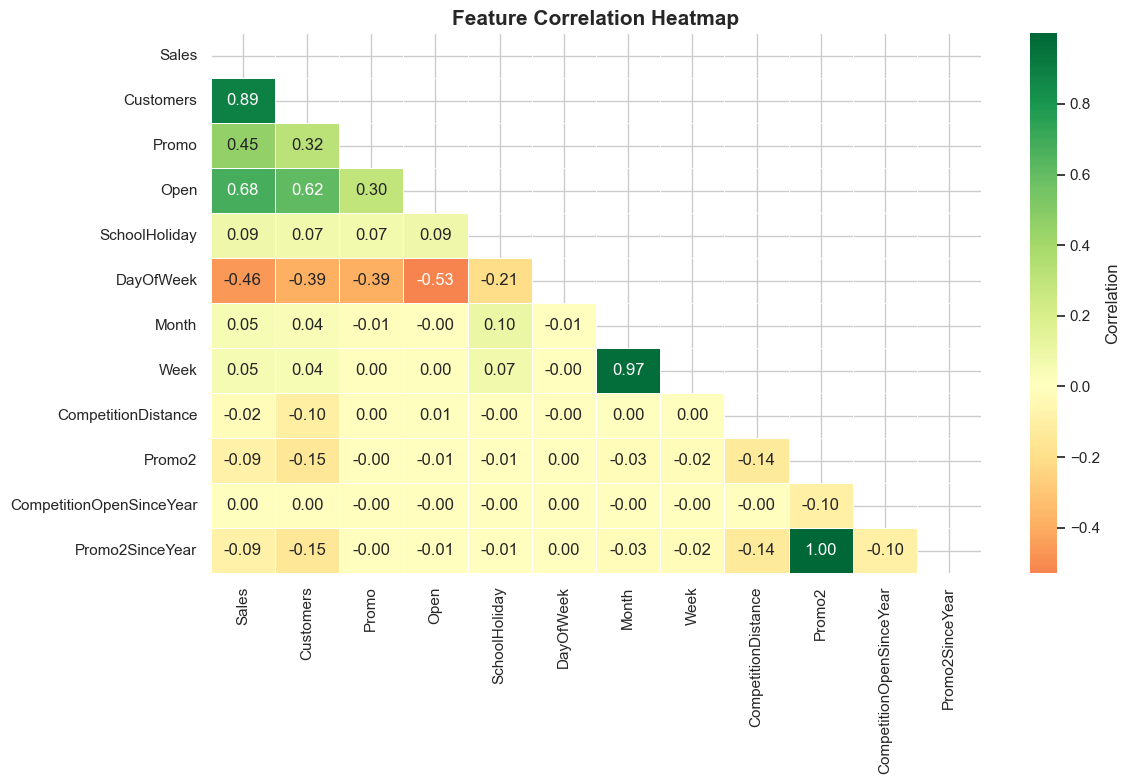

📊 Feature Correlations with Sales (sorted):
---------------------------------------------
   Customers                    : +0.895  █████████████████
   Open                         : +0.678  █████████████
   Promo                        : +0.452  █████████
   SchoolHoliday                : +0.085  █
   Week                         : +0.053  █
   Month                        : +0.049  
   CompetitionOpenSinceYear     : +0.003  
   CompetitionDistance          : -0.019  
   Promo2                       : -0.091  █
   Promo2SinceYear              : -0.091  █
   DayOfWeek                    : -0.462  █████████


In [17]:
# ── Select numerical columns only ────────────────────────────────
num_cols = ['Sales', 'Customers', 'Promo', 'Open',
            'SchoolHoliday', 'DayOfWeek', 'Month', 'Week',
            'CompetitionDistance', 'Promo2',
            'CompetitionOpenSinceYear', 'Promo2SinceYear']

corr_df = df[num_cols].corr()

# ── Plot heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True          # Hide upper triangle

sns.heatmap(corr_df,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Correlation'})

ax.set_title('Feature Correlation Heatmap', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Top correlations with Sales ───────────────────────────────────
print("📊 Feature Correlations with Sales (sorted):")
print("-" * 45)
sales_corr = corr_df['Sales'].drop('Sales').sort_values(ascending=False)
for feat, val in sales_corr.items():
    direction = "+" if val > 0 else ""
    bar = "█" * int(abs(val) * 20)
    print(f"   {feat:<28} : {direction}{val:.3f}  {bar}")

## EDA Summary — Key Business Insights

| # | Insight | Impact |
|---|---------|--------|
| 1 | December is peak sales month — Christmas drives €231M | High |
| 2 | February & August are weakest months | Medium |
| 3 | 2015 outperforming previous years Jan-Jul | High |
| 4 | Monday & Sunday have highest daily sales | Medium |
| 5 | Store 262 is best (€19.5M) vs Store 972 worst (€2.4M) — 8x gap | High |
| 6 | Store Type B generates 50% more sales than other types | High |
| 7 | Promotions drive +38.8% sales & +21.2% customer uplift | High |
| 8 | Type A stores most promo-sensitive (+43% uplift) | High |
| 9 | Easter & Christmas holidays drive +40% sales uplift | High |
| 10 | Customers & Promo are strongest ML features | High |

In [18]:
print("=" * 55)
print("   EDA COMPLETE — 01_EDA.ipynb")
print("=" * 55)
print()
print("📊 Dataset    : 1,017,209 rows | 18 features")
print("🏪 Stores     : 1,115 stores across Germany")
print("📅 Period     : Jan 2013 — Jul 2015")
print()
print("✅ Steps Completed:")
print("   1. Data Loading & Inspection")
print("   2. Missing Value Analysis & Treatment")
print("   3. Data Merging & Cleaning")
print("   4. Monthly & Weekly Sales Trends")
print("   5. Store Performance Analysis")
print("   6. Promotion Impact Analysis")
print("   7. Holiday Effects Analysis")
print("   8. Correlation Analysis")
print()
print("➡️  Next : 02_Feature_Engineering.ipynb")
print("=" * 55)

   EDA COMPLETE — 01_EDA.ipynb

📊 Dataset    : 1,017,209 rows | 18 features
🏪 Stores     : 1,115 stores across Germany
📅 Period     : Jan 2013 — Jul 2015

✅ Steps Completed:
   1. Data Loading & Inspection
   2. Missing Value Analysis & Treatment
   3. Data Merging & Cleaning
   4. Monthly & Weekly Sales Trends
   5. Store Performance Analysis
   6. Promotion Impact Analysis
   7. Holiday Effects Analysis
   8. Correlation Analysis

➡️  Next : 02_Feature_Engineering.ipynb
